## LangGraph添加人工操作的节点

In [1]:
import os
from typing import Literal, Annotated, TypedDict

from langchain.chat_models import init_chat_model
from langchain.schema import HumanMessage, AIMessage
from langchain_core.messages import ToolMessage
from langchain.tools.tavily_search import TavilySearchResults

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import (
    ToolNode,  # 如果想自定义可参考前面文章中的SelfToolNode
    tools_condition  # 也可以自定义条件边函数
)

### 1. 实例化应用准备

In [2]:
# MessageState
class State(TypedDict):
    messages: Annotated[list, add_messages]
    auto: bool = True

# 联网搜索工具
search_tool = TavilySearchResults(max_results=2)
# 工具列表
tools = [search_tool]

# 实例化模型
model_name = "qwen2.5:7b"
ollama_api_base = os.environ["OLLAMA_API_BASE"]
model = init_chat_model(model=model_name, model_provider="ollama", base_url=ollama_api_base)
# 模型绑定工具
model_with_tools = model.bind_tools(tools)

# chatbot节点
def chatbot(state: State):
    return {
        "messages": [model_with_tools.invoke(state["messages"])]
    }

# tools节点
tool_node = ToolNode(tools=tools)

### 2. 实例化Graph应用

In [3]:
# 实例化graph builder
workflow = StateGraph(State)

# 添加节点
workflow.add_node("chatbot", chatbot)
workflow.add_node("tools", tool_node)

# 添加条件边
workflow.add_conditional_edges("chatbot", tools_condition)

# 给工具调用完后添加边：指向chatbot
workflow.add_edge("tools", "chatbot")

# 设置入口节点
workflow.set_entry_point("chatbot")

# 检查点
memory = MemorySaver()

# 编译应用：设置人工操作的节点，这里interrupt_before是重点！！！！
app = workflow.compile(
    # 执行tools节点之前都会进行打断
    checkpointer=memory, interrupt_before=["tools"]
)

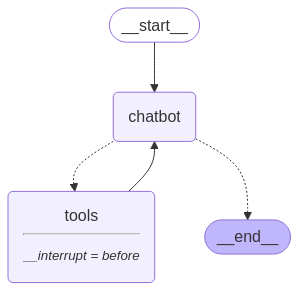

In [4]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

### 3. 体验打断

In [5]:
# 消息内容
messages = [
    HumanMessage(content="请给我查询深圳的天气")
]

# 配置
config = {"configurable": {"thread_id": "123"}}

events = app.stream({"messages": messages}, config=config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()


================================ Human Message =================================

请给我查询深圳的天气
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (6d7aa9c2-30d3-48eb-828b-7d361b9804f1)
 Call ID: 6d7aa9c2-30d3-48eb-828b-7d361b9804f1
  Args:
    query: 深圳天气


> 现在我们看到了即将调用的工具和其参数。

In [6]:
# 获取当前的状态
current_state = app.get_state(config)
# 查看当前状态下一个即将执行的节点
current_state.next

('tools',)

In [7]:
# 查看当前状态的最后一条消息
current_state.values["messages"][-1]

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2025-03-06T07:47:10.643063Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1183912583, 'load_duration': 37313833, 'prompt_eval_count': 193, 'prompt_eval_duration': 234000000, 'eval_count': 44, 'eval_duration': 909000000, 'message': {'role': 'assistant', 'content': '', 'images': None, 'tool_calls': None}}, id='run-6dc20d3d-3f52-497c-b0fa-ce82680fe8cd-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': '深圳天气'}, 'id': '6d7aa9c2-30d3-48eb-828b-7d361b9804f1', 'type': 'tool_call'}], usage_metadata={'input_tokens': 193, 'output_tokens': 44, 'total_tokens': 237})

In [8]:
# 查看tool_calls字段
current_state_last_message = current_state.values["messages"][-1]
if hasattr(current_state_last_message, "tool_calls"):
    print(current_state_last_message.tool_calls)

[{'name': 'tavily_search_results_json', 'args': {'query': '深圳天气'}, 'id': '6d7aa9c2-30d3-48eb-828b-7d361b9804f1', 'type': 'tool_call'}]


### 4. 让流程继续执行
> 前面我们已经体验到了流程的打断，那接下来就是让流程继续执行了。

#### 4.1 传递个None让流程继续执行

In [9]:
# 最开始我们运行的时候传递的是个{"messages": []}, 这里传递的直接是None
events = app.stream(None, config=config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (6d7aa9c2-30d3-48eb-828b-7d361b9804f1)
 Call ID: 6d7aa9c2-30d3-48eb-828b-7d361b9804f1
  Args:
    query: 深圳天气
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://weather.cma.cn/web/weather/59493.html", "content": "主站首页 领导主站 部门概况 新闻资讯 信息公开 服务办事 天气预报 首页 天气实况 气象公报 气象预警 城市预报 天气资讯 气象专题 气象科普 首页 国内 广东 深圳 国内  广东  深圳  更新 7天天气预报（2025/02/08 08:00发布） 星期六 多云 无持续风向 微风 16℃ 7℃ 多云 无持续风向 微风 星期日 无持续风向 微风 17℃ 7℃ 无持续风向 微风 星期一 多云 无持续风向 微风 19℃ 10℃ 多云 无持续风向 微风 星期二 多云 无持续风向 微风 21℃ 17℃ 多云 无持续风向 微风 星期三 多云 无持续风向 微风 23℃ 17℃ 无持续风向 微风 星期四 无持续风向 微风 22℃ 16℃ 东风 3~4级 星期五 多云 无持续风向 微风 21℃ 14℃ 中雨 无持续风向 微风 时间 11:00   14:00   17:00   20:00   23:00   02:00   05:00   08:00 天气                            气温 13℃ 16℃ 14.5℃   13.2℃   11.5℃   10.4℃   7.8℃    8.7℃ 降水 无降水 无降水 无降水 无降水 无降水 无降水 无降水 无降水 南方地区有较大范围雨雪天气 琼州海峡等海域有大雾 中东部地区有较大范围雨

---
**可以看到：** 执行`app.stream(None, config=config, stream_mode="values")`后跟未打断的情况的效果是一样的。

这样，langgraph应用在保存了检查点后，可以人工介入是否执行下一步操作了。

那么接下来，我们就体验一下人工修改执行状态。比如查询某次考试的成绩。我这里直接手动传递分数。

### 5. 手动更新状态
> 前面我们知道了怎么打断流程的执行，也知道了怎么继续让流程执行。那接下来，我们人工操作修改检查点中的状态。

#### 5.1 执行消息触发打断

In [10]:
# 消息内容
messages = [
    HumanMessage(content="请搜索alex的考试成绩，并给其分个等级ABCD四个等级")
]

# 配置
config = {"configurable": {"thread_id": "abc"}}

events = app.stream({"messages": messages}, config=config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

请搜索alex的考试成绩，并给其分个等级ABCD四个等级
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (1fc18c52-d5e6-43fb-b732-8353c008fbd6)
 Call ID: 1fc18c52-d5e6-43fb-b732-8353c008fbd6
  Args:
    query: Alex考试成绩


#### 5.2 手动更新状态
> 我们执行`app.stream(None, config=config, stream_mode="values")`可以让流程继续执行。
> 
> 这里我们想手动修改模拟调用工具后传递数据。

In [11]:
current_state = app.get_state(config)
current_state.values

{'messages': [HumanMessage(content='请搜索alex的考试成绩，并给其分个等级ABCD四个等级', additional_kwargs={}, response_metadata={}, id='510a8803-94a4-44d0-8404-2ab399bfefe0'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2025-03-06T07:47:20.204043Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2527014958, 'load_duration': 14319125, 'prompt_eval_count': 203, 'prompt_eval_duration': 99000000, 'eval_count': 114, 'eval_duration': 2411000000, 'message': {'role': 'assistant', 'content': '', 'images': None, 'tool_calls': None}}, id='run-bcce8a8f-f9b7-4782-8761-6b2d63bd9538-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Alex考试成绩'}, 'id': '1fc18c52-d5e6-43fb-b732-8353c008fbd6', 'type': 'tool_call'}], usage_metadata={'input_tokens': 203, 'output_tokens': 114, 'total_tokens': 317})]}

**准备新的消息：**

In [12]:
# 查看tool_calls字段
current_state_last_message = current_state.values["messages"][-1]
if hasattr(current_state_last_message, "tool_calls"):
    print(current_state_last_message.tool_calls)

# 这里假如我们通过调用了某个工具，查询到了结果，然后传给流程
new_messages = [
    ToolMessage(
        content="本次考试总分是100分，alex的考试成绩是99分,", 
        tool_call_id=current_state_last_message.tool_calls[0]["id"]
    ),
    # AIMessage(content="成绩是99分，非常不错！优秀")
]

for msg in new_messages:
    msg.pretty_print()

[{'name': 'tavily_search_results_json', 'args': {'query': 'Alex考试成绩'}, 'id': '1fc18c52-d5e6-43fb-b732-8353c008fbd6', 'type': 'tool_call'}]
================================= Tool Message =================================

本次考试总分是100分，alex的考试成绩是99分,


**把消息更新到状态中：**

In [13]:
# app.update_state?

In [14]:
app.update_state(
    # 传入配置，才知道更新哪个状态机 state
    config=config,
    # 提供更新的值
    values={"messages": new_messages},
    # 作为哪个节点的消息
    as_node="tools"
)

{'configurable': {'thread_id': 'abc',
  'checkpoint_ns': '',
  'checkpoint_id': '1effa5f3-bb64-6c26-8002-911b7e92dbd4'}}

**打印消息看下：**

In [15]:
for msg in app.get_state(config).values["messages"][-3:]:
    msg.pretty_print()

================================ Human Message =================================

请搜索alex的考试成绩，并给其分个等级ABCD四个等级
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (1fc18c52-d5e6-43fb-b732-8353c008fbd6)
 Call ID: 1fc18c52-d5e6-43fb-b732-8353c008fbd6
  Args:
    query: Alex考试成绩
================================= Tool Message =================================

本次考试总分是100分，alex的考试成绩是99分,


In [16]:
# 发现这里我们已经模拟出了工具的调用，那继续让流程执行
events = app.stream(None, config=config, stream_mode="values")

# 打印出消息
for event in events:
    # print(event)
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================= Tool Message =================================

本次考试总分是100分，alex的考试成绩是99分,
================================== Ai Message ==================================

根据查询结果，本次考试总分是100分，Alex的成绩为99分。我们可以将其评价为最高级别的A等级。
